In [2]:
# Final Exam STAT 604 Duncan Newman

# QUESTION 1(a)

import pandas as pd
import statsmodels.api as sm


df = pd.read_csv("Problem1Data.csv")

print(df.head())



X = df["AGE"]
y = df["CHD"]

# Add intercept
X = sm.add_constant(X)

# Fit model
model = sm.Logit(y, X).fit()

# Summary
print(model.summary())



new_person = pd.DataFrame({
    "const": [1],
    "AGE": [64.5]
})

predicted_prob = model.predict(new_person)

print("\nPredicted Probability of CHD at age 64.5:")
print(predicted_prob[0])

   AGE  CHD
0   20    0
1   23    0
2   24    0
3   25    0
4   25    1
Optimization terminated successfully.
         Current function value: 0.536765
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    CHD   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.2145
Time:                        21:53:39   Log-Likelihood:                -53.677
converged:                       True   LL-Null:                       -68.331
Covariance Type:            nonrobust   LLR p-value:                 6.168e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3095      1.134    

In [3]:
# QUESTION 1(b)


import pandas as pd


df = pd.read_csv("Problem1Data.csv")


bins = [20, 30, 35, 40, 45, 50, 55, 60, 71]

labels = [
    "20-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-70"
]

df["age_interval"] = pd.cut(
    df["AGE"],
    bins=bins,
    labels=labels,
    right=False
)


midpoints = {
    "20-29": 24.5,
    "30-34": 32,
    "35-39": 37,
    "40-44": 42,
    "45-49": 47,
    "50-54": 52,
    "55-59": 57,
    "60-70": 65
}


freq_table = df.groupby("age_interval").agg(
    frequency=("CHD", "count"),
    CHD_cases=("CHD", "sum"),
    observed_proportion=("CHD", "mean")
).reset_index()

freq_table["agegroup"] = freq_table["age_interval"].map(midpoints)

freq_table = freq_table[
    [
        "age_interval",
        "agegroup",
        "frequency",
        "CHD_cases",
        "observed_proportion"
    ]
]

print(freq_table)

  age_interval agegroup  frequency  CHD_cases  observed_proportion
0        20-29     24.5         10          1             0.100000
1        30-34     32.0         15          2             0.133333
2        35-39     37.0         12          3             0.250000
3        40-44     42.0         15          5             0.333333
4        45-49     47.0         13          6             0.461538
5        50-54     52.0          8          5             0.625000
6        55-59     57.0         17         13             0.764706
7        60-70     65.0         10          8             0.800000


/tmp/ipykernel_25951/3636401476.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_table = df.groupby("age_interval").agg(


/tmp/ipykernel_25951/1555754987.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs = df.groupby("age_interval")["CHD"].mean().reset_index()


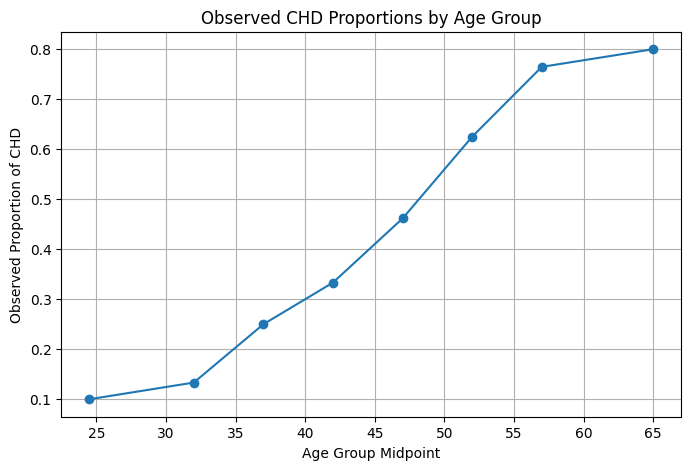

In [4]:
# QUESTION 1(c)


import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("Problem1Data.csv")


bins = [20, 30, 35, 40, 45, 50, 55, 60, 71]

labels = [
    "20-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-70"
]

df["age_interval"] = pd.cut(
    df["AGE"],
    bins=bins,
    labels=labels,
    right=False
)

midpoints = {
    "20-29": 24.5,
    "30-34": 32,
    "35-39": 37,
    "40-44": 42,
    "45-49": 47,
    "50-54": 52,
    "55-59": 57,
    "60-70": 65
}


obs = df.groupby("age_interval")["CHD"].mean().reset_index()

obs["agegroup"] = obs["age_interval"].map(midpoints)


plt.figure(figsize=(8,5))

plt.plot(
    obs["agegroup"],
    obs["CHD"],
    marker="o"
)

plt.xlabel("Age Group Midpoint")
plt.ylabel("Observed Proportion of CHD")

plt.title("Observed CHD Proportions by Age Group")

plt.grid(True)

plt.show()

Optimization terminated successfully.
         Current function value: 0.536765
         Iterations 6
  age_interval       CHD agegroup    fitted  logit_hat
0        20-29  0.100000     24.5  0.069662  -2.591885
1        30-34  0.133333     32.0  0.146793  -1.759977
2        35-39  0.250000     37.0  0.230521  -1.205371
3        40-44  0.333333     42.0  0.342817  -0.650765
4        45-49  0.461538     47.0  0.475979  -0.096160
5        50-54  0.625000     52.0  0.612645   0.458446
6        55-59  0.764706     57.0  0.733617   1.013052
7        60-70  0.800000     65.0  0.869939   1.900421


/tmp/ipykernel_25951/762195050.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison = df.groupby("age_interval")["CHD"].mean().reset_index()


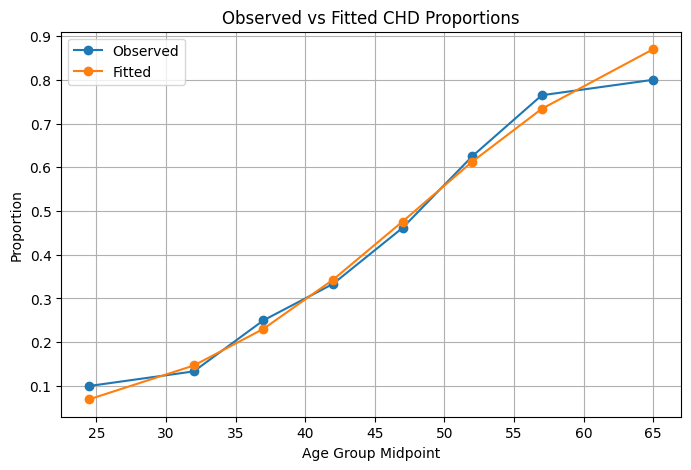

In [5]:
# QUESTION 1(d)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


df = pd.read_csv("Problem1Data.csv")


X = sm.add_constant(df["AGE"])
y = df["CHD"]

model = sm.Logit(y, X).fit()


bins = [20, 30, 35, 40, 45, 50, 55, 60, 71]

labels = [
    "20-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-70"
]

df["age_interval"] = pd.cut(
    df["AGE"],
    bins=bins,
    labels=labels,
    right=False
)

midpoints = {
    "20-29": 24.5,
    "30-34": 32,
    "35-39": 37,
    "40-44": 42,
    "45-49": 47,
    "50-54": 52,
    "55-59": 57,
    "60-70": 65
}

comparison = df.groupby("age_interval")["CHD"].mean().reset_index()

comparison["agegroup"] = comparison["age_interval"].map(midpoints)


newX = pd.DataFrame({
    "const": 1,
    "AGE": comparison["agegroup"]
})

comparison["fitted"] = model.predict(newX)

comparison["logit_hat"] = np.log(
    comparison["fitted"] /
    (1 - comparison["fitted"])
)

print(comparison)


plt.figure(figsize=(8,5))

plt.plot(
    comparison["agegroup"],
    comparison["CHD"],
    marker="o",
    label="Observed"
)

plt.plot(
    comparison["agegroup"],
    comparison["fitted"],
    marker="o",
    label="Fitted"
)

plt.xlabel("Age Group Midpoint")
plt.ylabel("Proportion")

plt.title("Observed vs Fitted CHD Proportions")

plt.legend()

plt.grid(True)

plt.show()

In [6]:
# QUESTION 1(e)

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import chi2


df = pd.read_csv("Problem1Data.csv")


X = sm.add_constant(df["AGE"])
y = df["CHD"]

model = sm.Logit(y, X).fit()


bins = [20, 30, 35, 40, 45, 50, 55, 60, 71]

labels = [
    "20-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-70"
]

df["age_interval"] = pd.cut(
    df["AGE"],
    bins=bins,
    labels=labels,
    right=False
)

midpoints = {
    "20-29": 24.5,
    "30-34": 32,
    "35-39": 37,
    "40-44": 42,
    "45-49": 47,
    "50-54": 52,
    "55-59": 57,
    "60-70": 65
}


gof = df.groupby("age_interval").agg(
    n=("CHD", "count"),
    observed=("CHD", "sum")
).reset_index()

gof["agegroup"] = gof["age_interval"].map(midpoints)


newX = pd.DataFrame({
    "const": 1,
    "AGE": gof["agegroup"]
})

gof["p_hat"] = model.predict(newX)

# Expected counts
gof["expected"] = gof["n"] * gof["p_hat"]


pearson = np.sum(
    (gof["observed"] - gof["expected"])**2 /
    gof["expected"]
)


g_stat = 2 * np.sum(
    gof["observed"] *
    np.log(gof["observed"] / gof["expected"])
)

# Degrees of freedom
dfree = 6

# p-values
pearson_p = 1 - chi2.cdf(pearson, dfree)
g_p = 1 - chi2.cdf(g_stat, dfree)

print("Pearson Chi-Square Statistic:", pearson)
print("Pearson p-value:", pearson_p)

print("\nLikelihood Ratio Statistic:", g_stat)
print("Likelihood Ratio p-value:", g_p)

Optimization terminated successfully.
         Current function value: 0.536765
         Iterations 6
Pearson Chi-Square Statistic: 0.2606303148124306
Pearson p-value: 0.9996653995890731

Likelihood Ratio Statistic: 0.11258481134699111
Likelihood Ratio p-value: 0.9999714971393433


/tmp/ipykernel_25951/3135905121.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gof = df.groupby("age_interval").agg(


  CountryCode  m100(sec)  m200(sec)  m400(sec)  m800(min)  m1500(min)  \
0         ARG      11.57      22.94      52.50       2.05        4.25   
1         AUS      11.12      22.23      48.63       1.98        4.02   
2         AUT      11.15      22.70      50.62       1.94        4.05   
3         BEL      11.14      22.48      51.45       1.97        4.08   
4         BER      11.46      23.05      53.30       2.07        4.29   

   m3000(min)  Marathon(min)  
0        9.19         150.32  
1        8.63         143.51  
2        8.78         154.35  
3        8.82         143.05  
4        9.81         174.18  
           Country  NOC ISO code
0      Afghanistan  AFG       AF
1          Albania  ALB       AL
2          Algeria  ALG       DZ
3  American Samoa*  ASA       AS
4          Andorra  AND       AD

Explained Variance Ratio:
[0.83318426 0.09252242 0.03138005 0.01842512 0.01424689 0.00803703
 0.00220423]

Cumulative Variance:
[0.83318426 0.92570668 0.95708673 0.97551185 0.9

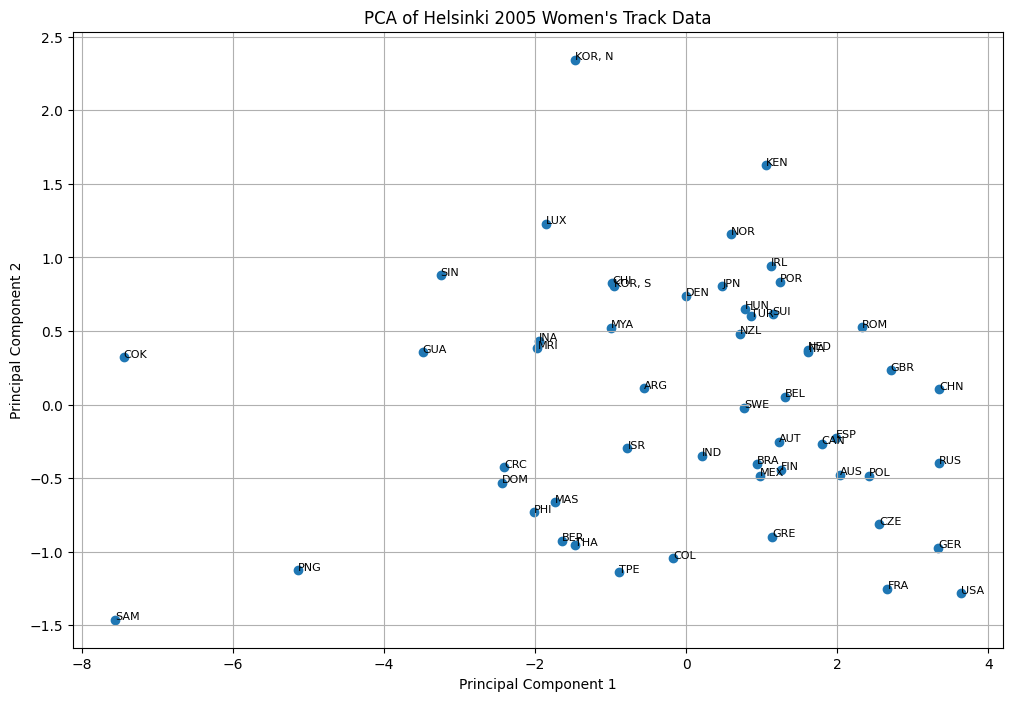

In [9]:
# QUESTION 2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


track = pd.read_csv("Helsinki2005WomensTrackData.csv")

country_codes = pd.read_csv("CountryCodes.csv")

print(track.head())
print(country_codes.head())


track["speed100"] = 100 / track["m100(sec)"]
track["speed200"] = 200 / track["m200(sec)"]
track["speed400"] = 400 / track["m400(sec)"]

track["speed800"] = 800 / (track["m800(min)"] * 60)
track["speed1500"] = 1500 / (track["m1500(min)"] * 60)
track["speed3000"] = 3000 / (track["m3000(min)"] * 60)

track["speedMarathon"] = 42195 / (track["Marathon(min)"] * 60)


speed_data = track[
    [
        "speed100",
        "speed200",
        "speed400",
        "speed800",
        "speed1500",
        "speed3000",
        "speedMarathon"
    ]
]


scaler = StandardScaler()

speed_scaled = scaler.fit_transform(speed_data)


pca = PCA()

scores = pca.fit_transform(speed_scaled)


print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative Variance:")
print(np.cumsum(pca.explained_variance_ratio_))


pca_df = pd.DataFrame(
    scores,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5",
        "PC6",
        "PC7"
    ]
)


pca_df["NOC"] = track["CountryCode"]


pca_df = pd.merge(
    pca_df,
    country_codes,
    on="NOC",
    how="left"
)


ranking = pca_df.sort_values(
    by="PC1",
    ascending=False
)

print("\nCountry Rankings Based on PC1:")
print(
    ranking[
        [
            "Country",
            "NOC",
            "PC1"
        ]
    ]
)


loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        "PC1",
        "PC2",
        "PC3",
        "PC4",
        "PC5",
        "PC6",
        "PC7"
    ],
    index=speed_data.columns
)

print("\nPCA Loadings:")
print(loadings)

plt.figure(figsize=(12,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

for i in range(len(pca_df)):
    plt.text(
        pca_df["PC1"][i],
        pca_df["PC2"][i],
        pca_df["NOC"][i],
        fontsize=8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA of Helsinki 2005 Women's Track Data")

plt.grid(True)

plt.show()

   Wind   Solar Radiation  Carbon Monoxide (CO)  Nitrogen Monoxide (NO)  \
0      8               98                     7                       2   
1      7              107                     4                       3   
2      7              103                     4                       3   
3     10               88                     5                       2   
4      6               91                     4                       2   

   Nitrogen dioxide (NO2)  Ozone (O3)  Hydrocarbons (HC)  
0                      12           8                  2  
1                       9           5                  3  
2                       5           6                  3  
3                       8          15                  4  
4                       8          10                  3  

Covariance PCA Variance Explained:
[8.72948001e-01 8.11271357e-02 3.28928146e-02 7.24256858e-03
 3.67109161e-03 1.51697887e-03 6.01409649e-04]

Cumulative Variance:
[0.872948   0.95407514 0.9869

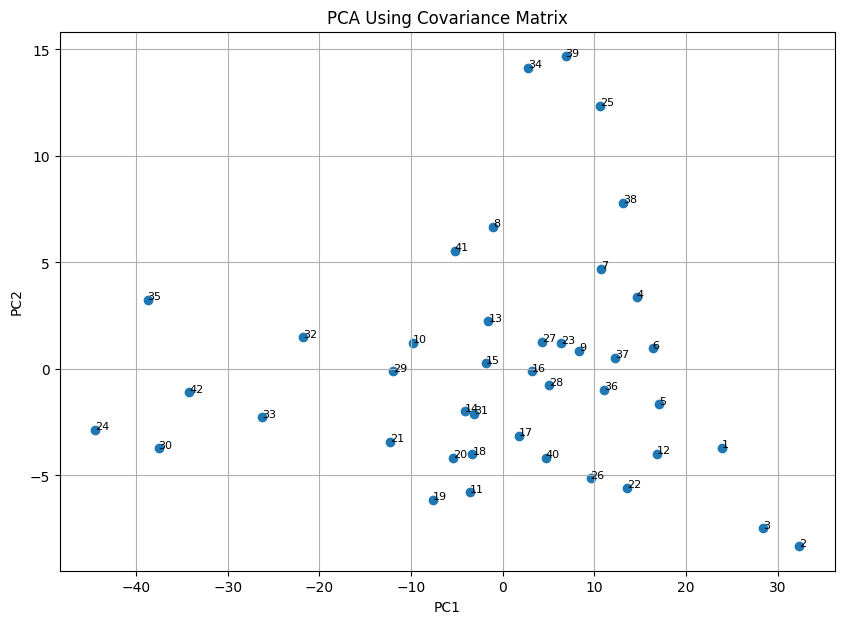


Covariance PCA Loadings:
                             PC1       PC2       PC3       PC4       PC5  \
Wind                   -0.010039 -0.076224 -0.030878  0.920305  0.342386   
Solar Radiation         0.993199 -0.116155 -0.006591 -0.000212  0.002239   
Carbon Monoxide (CO)    0.014062  0.099568  0.182826 -0.138292  0.650078   
Nitrogen Monoxide (NO) -0.004710 -0.013204  0.130216 -0.327784  0.643156   
Nitrogen dioxide (NO2)  0.024256  0.150381  0.955263  0.102372 -0.206584   
Ozone (O3)              0.112430  0.973359 -0.169810  0.063248 -0.000294   
Hydrocarbons (HC)       0.002341  0.023820  0.085196  0.109507  0.061961   

                             PC6       PC7  
Wind                    0.011779 -0.169730  
Solar Radiation         0.003353 -0.001782  
Carbon Monoxide (CO)   -0.563894  0.443578  
Nitrogen Monoxide (NO)  0.497513 -0.462856  
Nitrogen dioxide (NO2) -0.009009 -0.105030  
Ozone (O3)              0.051067 -0.066992  
Hydrocarbons (HC)       0.657012  0.738019  

Corr

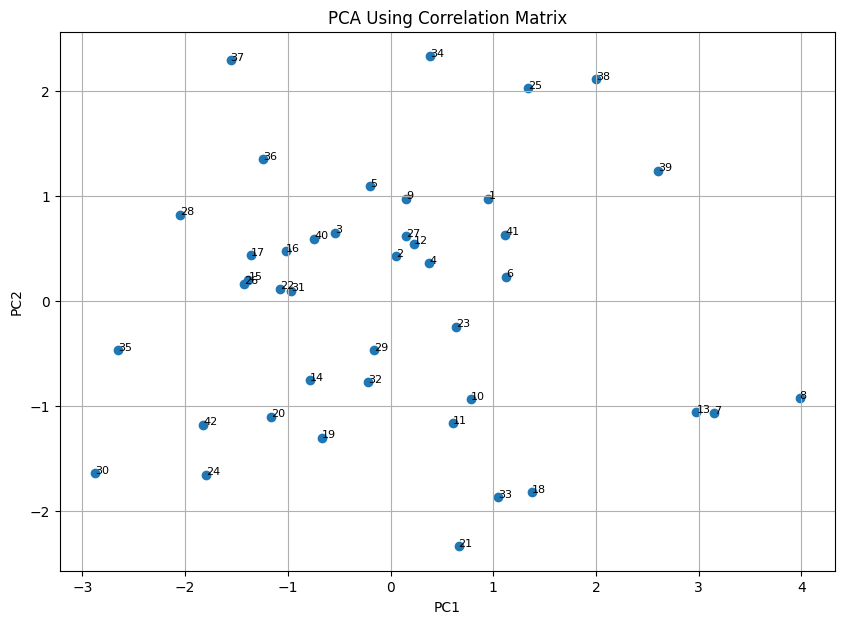


Correlation PCA Loadings:
                             PC1       PC2       PC3       PC4       PC5  \
Wind                   -0.236821 -0.278445  0.643474  0.172719  0.560534   
Solar Radiation         0.205567  0.526614  0.224469  0.778137 -0.156134   
Carbon Monoxide (CO)    0.551084  0.006820 -0.113609  0.005302  0.573422   
Nitrogen Monoxide (NO)  0.377615 -0.434674 -0.407098  0.290503 -0.056691   
Nitrogen dioxide (NO2)  0.498016 -0.199767  0.196557 -0.042428  0.050214   
Ozone (O3)              0.324551  0.566974  0.159847 -0.507916  0.080243   
Hydrocarbons (HC)       0.319403 -0.307883  0.541048 -0.143082 -0.566071   

                             PC6       PC7  
Wind                   -0.223579 -0.241467  
Solar Radiation        -0.005701 -0.011265  
Carbon Monoxide (CO)   -0.109539  0.585246  
Nitrogen Monoxide (NO) -0.450235 -0.460890  
Nitrogen dioxide (NO2)  0.744969 -0.337844  
Ozone (O3)             -0.330583 -0.417078  
Hydrocarbons (HC)      -0.266470  0.313914  


In [10]:
# QUESTION 3


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pollution = pd.read_csv("LAAirPollution.csv")

print(pollution.head())


pca_cov = PCA()

cov_scores = pca_cov.fit_transform(pollution)


cov_var = pca_cov.explained_variance_ratio_

print("\nCovariance PCA Variance Explained:")
print(cov_var)

print("\nCumulative Variance:")
print(np.cumsum(cov_var))

# PCs needed for 90%
cov_90 = np.argmax(np.cumsum(cov_var) >= 0.90) + 1

print("\nNumber of PCs for 90% variance (Covariance):")
print(cov_90)


cov_df = pd.DataFrame(
    cov_scores[:, 0:2],
    columns=["PC1", "PC2"]
)

cov_df["Location"] = range(1, len(cov_df)+1)

plt.figure(figsize=(10,7))

plt.scatter(
    cov_df["PC1"],
    cov_df["PC2"]
)

for i in range(len(cov_df)):
    plt.text(
        cov_df["PC1"][i],
        cov_df["PC2"][i],
        str(cov_df["Location"][i]),
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Using Covariance Matrix")

plt.grid(True)

plt.show()


cov_loadings = pd.DataFrame(
    pca_cov.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pollution.columns))],
    index=pollution.columns
)

print("\nCovariance PCA Loadings:")
print(cov_loadings)


scaler = StandardScaler()

pollution_scaled = scaler.fit_transform(pollution)

pca_cor = PCA()

cor_scores = pca_cor.fit_transform(pollution_scaled)


cor_var = pca_cor.explained_variance_ratio_

print("\nCorrelation PCA Variance Explained:")
print(cor_var)

print("\nCumulative Variance:")
print(np.cumsum(cor_var))

# PCs needed for 90%
cor_90 = np.argmax(np.cumsum(cor_var) >= 0.90) + 1

print("\nNumber of PCs for 90% variance (Correlation):")
print(cor_90)


cor_df = pd.DataFrame(
    cor_scores[:, 0:2],
    columns=["PC1", "PC2"]
)

cor_df["Location"] = range(1, len(cor_df)+1)

plt.figure(figsize=(10,7))

plt.scatter(
    cor_df["PC1"],
    cor_df["PC2"]
)

for i in range(len(cor_df)):
    plt.text(
        cor_df["PC1"][i],
        cor_df["PC2"][i],
        str(cor_df["Location"][i]),
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Using Correlation Matrix")

plt.grid(True)

plt.show()


cor_loadings = pd.DataFrame(
    pca_cor.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pollution.columns))],
    index=pollution.columns
)

print("\nCorrelation PCA Loadings:")
print(cor_loadings)